# <span style="font-size: 150%;">News Vietnameses Summary</span>.

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## Enviroment setting

In [2]:
!pip install underthesea beautifulsoup4 transformers torch tqdm pandas

import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
from underthesea import word_tokenize
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel
import torch

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from datetime import datetime
import unicodedata

from collections import Counter
import itertools

from sklearn.model_selection import train_test_split
import os

import tiktoken

tqdm.pandas()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.6/978.6 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

### Config colab



In [3]:
# # Comment các cell liên quan đến colab nến ở kaggle và ngược lại*

# import kagglehub
# phamtheds_news_dataset_vietnameses_path = kagglehub.dataset_download('phamtheds/news-dataset-vietnameses')

# print('Data source import complete.')


# from google.colab import drive
# drive.mount('/content/drive')

# import os

# print('Đường dẫn thư mục dataset', phamtheds_news_dataset_vietnameses_path)

# print("\nCác file trong dataset:")
# print(os.listdir(phamtheds_news_dataset_vietnameses_path))

# csv_files = [f for f in os.listdir(phamtheds_news_dataset_vietnameses_path) if f.endswith('.csv')]

# if csv_files:
#     df = pd.read_csv(os.path.join(phamtheds_news_dataset_vietnameses_path, csv_files[0]))
#     print(df.head())

### Config kaggle

In [4]:
df = pd.read_csv("/kaggle/input/news-dataset-vietnameses/Dataset_articles_NoID.csv")

## Data review

In [5]:
pd.set_option('display.max_colwidth', None) # in ra hết dữ liệu
df.sample(n=1) # Ngẫu nhiên

,URL,Title,Summary,Contents,Date,Author(s),Category,Tags
242688,https://laodong.vn/bat-dong-san/cac-khu-do-thi-moi-tai-ha-noi-truoc-tran-mua-cang-xay-cang-lut-521676.ldo,"Các khu đô thị mới tại Hà Nội trước trận mưa: Càng xây, càng lụt!","Tại Hà Nội, các khu đô thị lớn sau trận mưa lớn từ đầu mùa vào cuối tháng 5 đều ngập nặng, có nhiều khu đô thị như An Khánh (Hoài Đức), Văn Phú (quận Hà Đông), khu Resco (Cổ Nhuế- Hà Đông) bị cô lập trong nhiều giờ. Theo nhiều ý kiến, việc ngập lụt các khu đô thị mới kéo dài không thể chấp nhận, cần quy rõ trách nhiệm cụ thể của chính quyền, lẫn chủ đầu tư khi xây dựng, vận hành các khu đô thị này.","Khu đô thị cao cấp thành “điểm đen” ngập lụt Tại Hà Nội, mỗi trận mưa lớn thì các cư dân chung cư, mặc dù sống trên cao vẫn hoảng sợ. Bởi lẽ, mưa thì phố lại thành sông, lụt lội kinh hoàng. Như đêm 24 rạng sáng 25.5 vừa qua, tại các khu đô thị Văn Phú (quận Hà Đông- do Cty CP Đầu tư Văn Phú - Invest) cũng bị ngập sâu vài chục cm, có chỗ ngập đến 60cm, khiến hàng loạt xe ô tô chết máy giữa đường. Khu đô thị Resco (phường Cổ Nhuế do HANDIRESCO và HANDICO làm chủ đầu tư) gần như cũng bị cô lập hoàn toàn. Các hộ dân không thể ra ngoài đi làm vì nước quá sâu. Người dân ở chung cư Thăng Long Victory (nằm trong Khu đô thị An Khánh, Hoài Đức do Phúc Hà Group làm chủ đầu tư) cũng khốn khổ vì bốn bề là biển nước. Đại lộ Thăng Long đoạn qua Khu chung cư Thăng Long Victory cũng bị ngập đến nửa xe máy, không thể đi lại. Việc ngập tại Hà Nội, đặc biệt là các khu đô thị mới là điều khó hiểu, bởi các khu đô thị này mới được hoàn thiện chỉ trong vòng 10 năm trở lại đây. Ngoài ra, hầu hết các khu đô thị này đều được quy hoạch đồng bộ với hạ tầng, đặc biệt là hệ thống thoát nước được xây dựng bài bản, kiên cố. Các chủ đầu tư khi bán nhà quảng bá với chất lượng sống Châu Âu. Tuy nhiên, khi mưa lớn đổ xuống thì có khi dân bơi xuồng đi làm. Ai chịu trách nhiệm? Giải thích điều khó hiểu khi hàng loạt các khu đô thị lớn vừa mới đưa vào hoàn thiện nhưng vẫn ngập lụt, Kiến trúc sư Trần Huy Ánh cho rằng, hệ thống thoát nước tại Hà Nội đã “có vấn đề” từ hơn 20 năm nay. Dù thành phố đã nỗ lực để giải quyết nhưng chưa có phương án nào đem lại hiệu quả triệt để. Nguyên nhân theo ông Ánh, là do quy hoạch yếu kém. “Quy hoạch ở đây được hiểu là gộp quy hoạch thoát nước và quy hoạch đô thị. Từ năm 2008, sau trận ngập lịch sử đến nay, Hà Nội vẫn chỉ có một quy hoạch thoát nước nhưng mật độ xây dựng và tầng cao tăng nhiều, công trình thoát nước mới lại không có gì đột phá. Đó là lý do nạn trũng ngập cũ chưa giải quyết xong thì lại nảy sinh nhiều nguy cơ mới”, ông Ánh nói. Còn theo PGS.TS Bùi Công Quang - chuyên gia quy hoạch hạ tầng- cho rằng quy hoạch xây dựng đô thị manh mún, thiếu quy hoạch tổng thể dẫn đến mâu thuẫn trong tiêu thoát nước giữa các tiểu khu. “Phát triển quy hoạch tùy tiện dẫn đến các khu vực dễ bị ngập lụt cục bộ, trong khi hệ thống tiêu thoát nước của khu vực không phù hợp và không đáp ứng được sự thay đổi ở các đô thị mới”, ông Quang nói. Tuy nhiên, giới chuyên gia cũng cho rằng, để xảy ra tình trạng ngập nặng còn do các chủ đầu tư khi phát triển các dự án bất động sản chỉ “chăm chăm” bán nhà mà bỏ quên, hoặc làm hạ tầng thoát nước qua quít, đối phó. Thực trạng của KĐT Văn Quán, mỗi lần có mưa là đường thành sông là ví dụ điển hình. Tương tự, cứ mưa lớn trên 100 mm kéo dài nhiều giờ, khu đô thị Resco, Thăng Long Victory bị cô lập. “Cần phải xem lại trách nhiệm của từng chủ đầu tư. Không thể có chuyện cứ bảo sống tiện nghi, cao cấp để bán nhà ào ào nhưng cứ mưa là ngập. Mưa lớn người dân lại lo thon thót đi mua mì gói dự phòng”, một kiến sư tại Hội quy hoạch kiến trúc Hà Nội nói. Người dân Hà Nội đang phải hứng đủ do sự cẩu thả, thiếu trách nhiệm của chính quyền lẫn chủ đầu tư!","Thứ sáu, 02/09/2016 13:09 (GMT+7)",T.Chí,Bất động sản,['Hà Nội']


In [6]:
print("Số dòng:", len(df))
print("Các cột:", df.columns.tolist())

Số dòng: 313320
Các cột: ['URL', 'Title', 'Summary', 'Contents', 'Date', 'Author(s)', 'Category', 'Tags']


In [7]:
# Kiểm tra kiểu dữ liệu, số lượng missing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313320 entries, 0 to 313319
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   URL        313320 non-null  object
 1   Title      313320 non-null  object
 2   Summary    313140 non-null  object
 3   Contents   307763 non-null  object
 4   Date       313320 non-null  object
 5   Author(s)  312499 non-null  object
 6   Category   313320 non-null  object
 7   Tags       313320 non-null  object
dtypes: object(8)
memory usage: 19.1+ MB


> Kích thước dataset lớn 313320 entries phù hợp fine turn ViT5, PhoGPT

In [8]:
# Số lương null, thiếu mỗi cột
print(df.isna().sum())

URL             0
Title           0
Summary       180
Contents     5557
Date            0
Author(s)     821
Category        0
Tags            0
dtype: int64




> Dữ liệu bị thếu nhiều ở cột summary, contents -> cần tiền xử lý



In [9]:
df_len = pd.DataFrame()

# Độ dài của các trường
df_len['len_URL'] = df['URL'].astype(str).apply(len)
df_len["len_title"] = df["Title"].astype(str).apply(len)
df_len["len_summary"] = df["Summary"].astype(str).apply(len)
df_len["len_contents"] = df["Contents"].astype(str).apply(len)
df_len["len_date"] = df["Date"].astype(str).apply(len)
df_len['len_Authors'] = df['Author(s)'].astype(str).apply(len)
df_len['len_category'] = df['Category'].astype(str).apply(len)
df_len['len_tabs'] = df['Tags'].astype(str).apply(len)


print("\nMô tả thống kê độ dài:")
print(df_len[['len_URL', "len_title", "len_summary", "len_contents",
          'len_date', 'len_Authors', 'len_category', 'len_tabs']].describe())


Mô tả thống kê độ dài:
             len_URL      len_title    len_summary   len_contents  \
count  313320.000000  313320.000000  313320.000000  313320.000000   
mean      100.961231      62.492228     191.594182    2273.304076   
std        12.331939      12.409977      76.616255    1775.232845   
min        41.000000       2.000000       3.000000       3.000000   
25%        94.000000      55.000000     137.000000    1362.000000   
50%       102.000000      64.000000     177.000000    2014.000000   
75%       109.000000      70.000000     230.000000    2819.000000   
max       256.000000     222.000000    1559.000000  186322.000000   

            len_date    len_Authors   len_category       len_tabs  
count  313320.000000  313320.000000  313320.000000  313320.000000  
mean       32.791411       9.659648       8.753284      89.487757  
std         0.614210       5.337122       3.233486      51.405804  
min        32.000000       1.000000       4.000000       6.000000  
25%        32.

In [10]:
# Kiểm tra trùng lặp URL
duplicate_url = df['URL'].duplicated().sum()
print(f'Số url trùng lặp: {duplicate_url}')

Số url trùng lặp: 23038


In [11]:
# Kiểm tra trùng lặp Title
dup_title = df['Title'].duplicated().sum()
print(f'Số Title trùng lặp: {dup_title}')

Số Title trùng lặp: 24487


In [12]:
# Kiểm tra trùng lặp Contents
dup_contents = df['Contents'].duplicated().sum()
print(f'Số Title trùng lặp: {dup_contents}')

Số Title trùng lặp: 28686


In [13]:
# Kiểm tra trùng lặp cả row
has_dup = df.duplicated().sum()
print('Sô dòng trùng lặp: ', has_dup)

Sô dòng trùng lặp:  23032


In [14]:
# Kiểm tra Title trùng với Summary
same = (df['Title'] == df['Summary']).sum()
print(f"Title = Summary: {same:,} dòng ({same/len(df)*100:.1f}%)")
if same > 0:
    print(df[df['Title'] == df['Summary']][['Title', 'Summary']].head(3))

Title = Summary: 5 dòng (0.0%)
                                                                                                       Title  \
83059   Báo Lao Động tuyển dụng vị trí Trưởng phòng và kỹ sư/kỹ thuật viên lập trình Ban Công nghệ thông tin   
120703                                                         Các doanh nghiệp nợ đang BHXH 3.261,5 tỉ đồng   
139126                                           Chính sách bảo hiểm, tiền lương có hiệu lực từ tháng 3.2022   

                                                                                                     Summary  
83059   Báo Lao Động tuyển dụng vị trí Trưởng phòng và kỹ sư/kỹ thuật viên lập trình Ban Công nghệ thông tin  
120703                                                         Các doanh nghiệp nợ đang BHXH 3.261,5 tỉ đồng  
139126                                           Chính sách bảo hiểm, tiền lương có hiệu lực từ tháng 3.2022  




> Xuất hiện dòng dữ liệu trùng lặp -> cần xử lý



Số dòng có Contents > 1200 từ: 8,241
Tỷ lệ: 2.63%
Số dòng có Contents < 50 từ: 7,133
Tỷ lệ: 2.28%


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Số lượng')

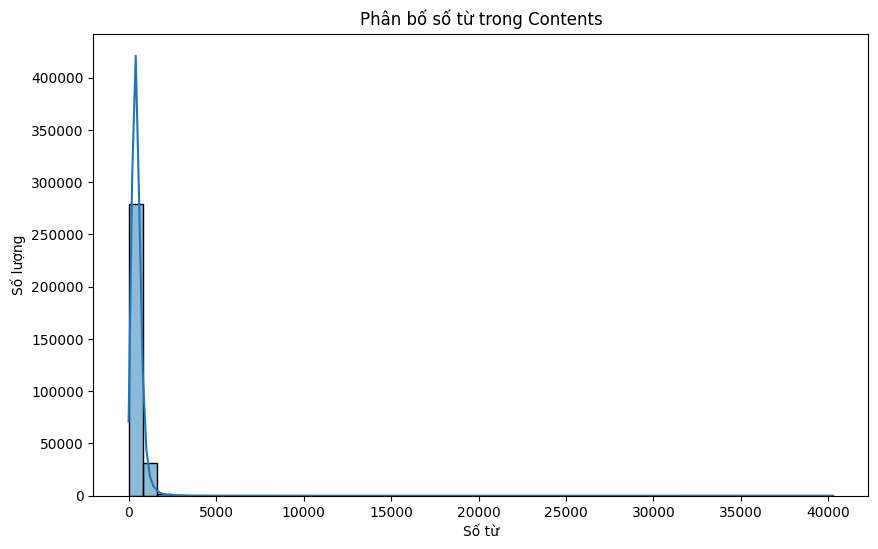

In [15]:
# Số lượng bài ngoài ngưỡng
df['word_count'] = df['Contents'].fillna('').str.count(' ') + 1

# Thống kê
under_50 = df[df['word_count'] < 50]
over_1200 = df[df['word_count'] > 1200]

print(f"Số dòng có Contents > 1200 từ: {len(over_1200):,}")
print(f"Tỷ lệ: {len(over_1200)/len(df)*100:.2f}%")

print(f"Số dòng có Contents < 50 từ: {len(under_50):,}")
print(f"Tỷ lệ: {len(under_50)/len(df)*100:.2f}%")

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Phân bố số từ trong Contents', fontsize=12)
plt.xlabel('Số từ')
plt.ylabel('Số lượng')

Số dòng có Title > 25 từ: 429
Tỷ lệ: 0.14%
Số dòng có Title < 3 từ: 42
Tỷ lệ: 0.01%


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Số lượng')

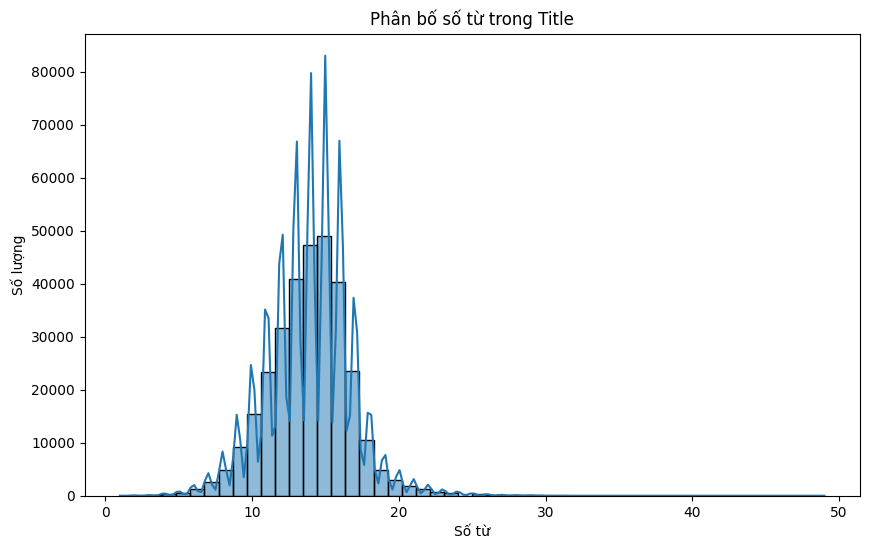

In [16]:
# Số lượng bài ngoài ngưỡng
df['word_count'] = df['Title'].fillna('').str.count(' ') + 1

# Thống kê
under_3 = df[df['word_count'] < 3]
over_25 = df[df['word_count'] > 25]

print(f"Số dòng có Title > 25 từ: {len(over_25):,}")
print(f"Tỷ lệ: {len(over_25)/len(df)*100:.2f}%")

print(f"Số dòng có Title < 3 từ: {len(under_3):,}")
print(f"Tỷ lệ: {len(under_3)/len(df)*100:.2f}%")

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Phân bố số từ trong Title', fontsize=12)
plt.xlabel('Số từ')
plt.ylabel('Số lượng')

Số dòng có Summary < 10 từ: 223
Tỷ lệ: 0.07%
Số dòng có Summary > 150 từ: 90
Tỷ lệ: 0.03%


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Số lượng')

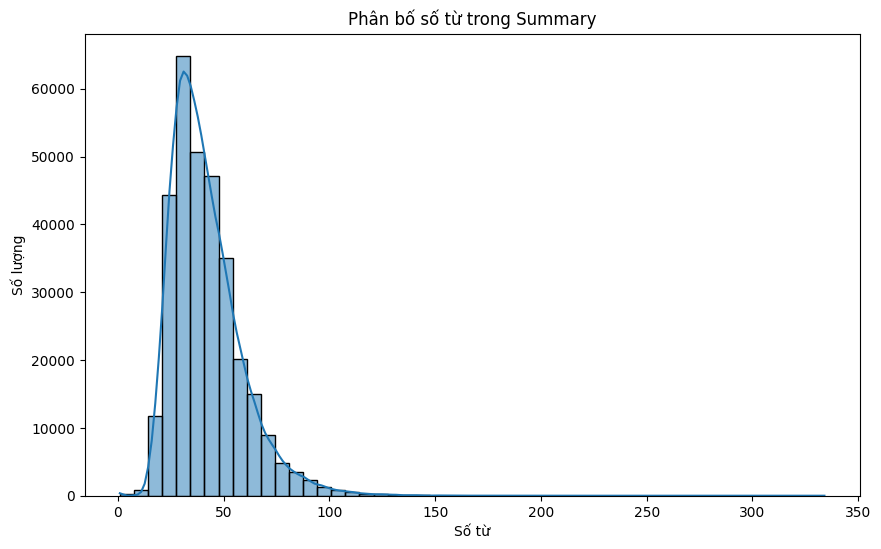

In [17]:
# Số lượng bài ngoài ngưỡng
df['word_count'] = df['Summary'].fillna('').str.count(' ') + 1

# Thống kê
under_10 = df[df['word_count'] < 10]
print(f"Số dòng có Summary < 10 từ: {len(under_10):,}")
print(f"Tỷ lệ: {len(under_10)/len(df)*100:.2f}%")

over_150 = df[df['word_count'] > 150]
print(f"Số dòng có Summary > 150 từ: {len(over_150):,}")
print(f"Tỷ lệ: {len(over_150)/len(df)*100:.2f}%")

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Phân bố số từ trong Summary', fontsize=12)
plt.xlabel('Số từ')
plt.ylabel('Số lượng')



> Có một lượng nhỏ bài báo có số từ trong Contents, Summary, Title quá ít, quá nhiều -> cần xử lý



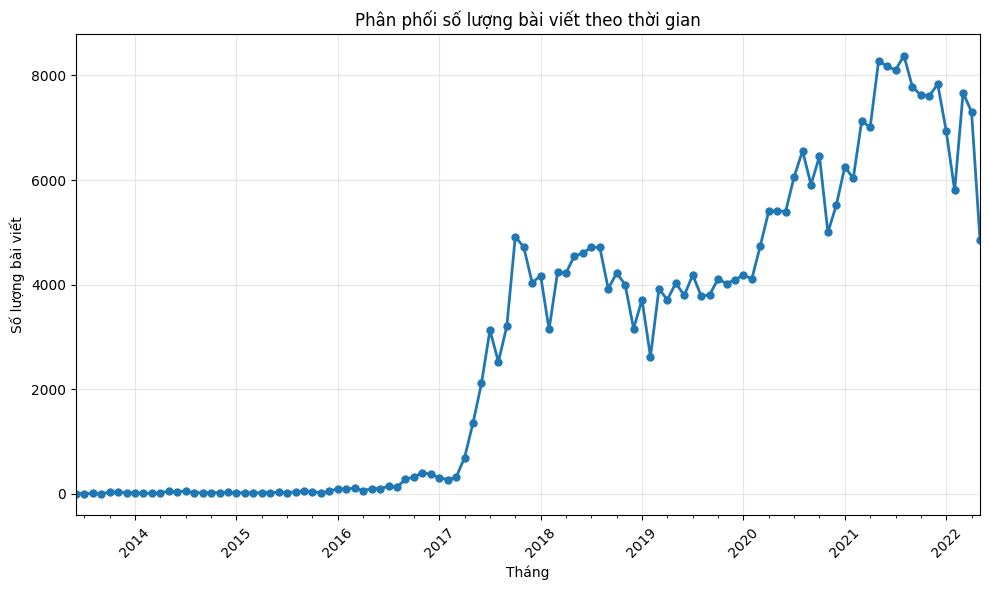

In [18]:
# Phân phối theo thời gian

def parse_vietnamese_date(date_str):
    try:
        # Tách phần ngày giờ (bỏ thứ và GMT)
        # VD: "Thứ năm, 18/07/2013 07:37 (GMT+7)" -> "18/07/2013 07:37"
        date_part = date_str.split(', ')[1].split(' (GMT')[0]
        return pd.to_datetime(date_part, format='%d/%m/%Y %H:%M')
    except:
        return pd.NaT

df['Date'] = df['Date'].apply(parse_vietnamese_date)

df_clean = df[df['Date'].notna()].copy()
# Tạo các cột phụ
df_clean['year'] = df_clean['Date'].dt.year
df_clean['month'] = df_clean['Date'].dt.month
df_clean['year_month'] = df_clean['Date'].dt.to_period('M')

# Biểu đồ phân phối theo tháng
plt.figure(figsize=(10, 6))
monthly_count = df_clean['year_month'].value_counts().sort_index()
monthly_count.plot(kind='line', marker='o', linewidth=2, markersize=5)
plt.xlabel('Tháng')
plt.ylabel('Số lượng bài viết')
plt.title('Phân phối số lượng bài viết theo thời gian')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

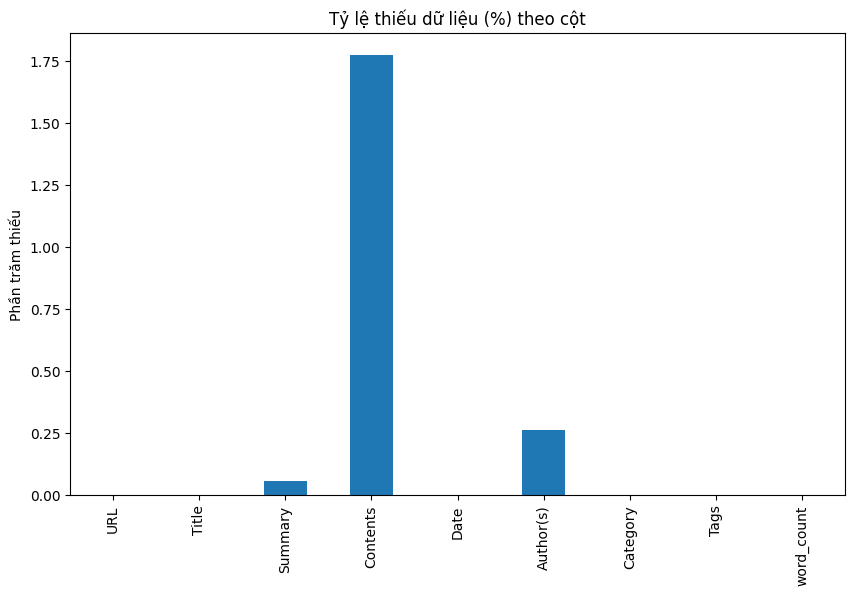

In [19]:
# Tỷ lệ thiếu dữ liệu
(df.isna().mean() * 100).plot(kind='bar', figsize=(10,6))
plt.title("Tỷ lệ thiếu dữ liệu (%) theo cột")
plt.ylabel("Phần trăm thiếu")
plt.show()

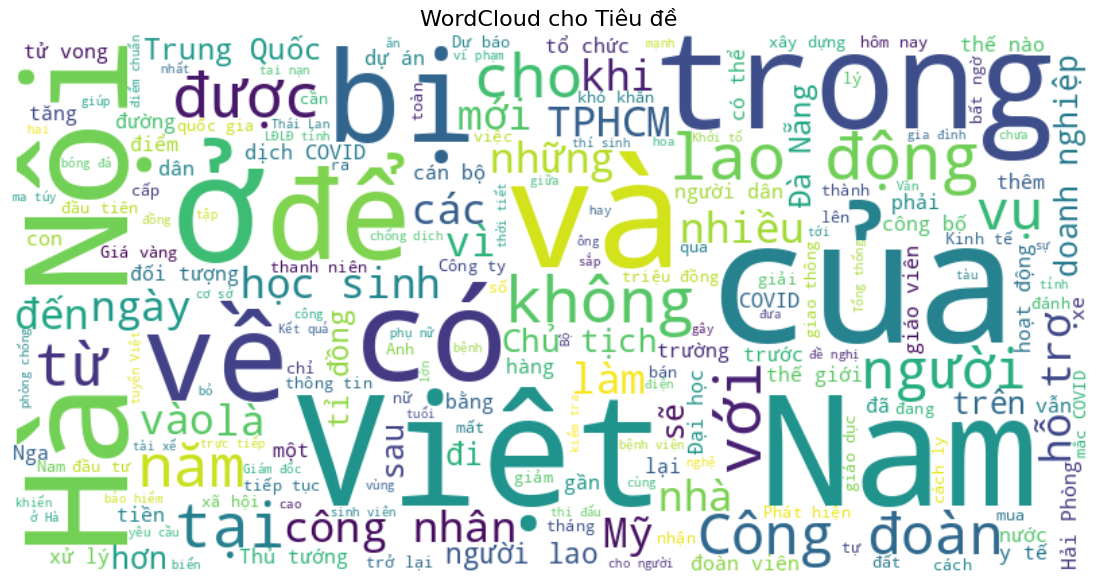

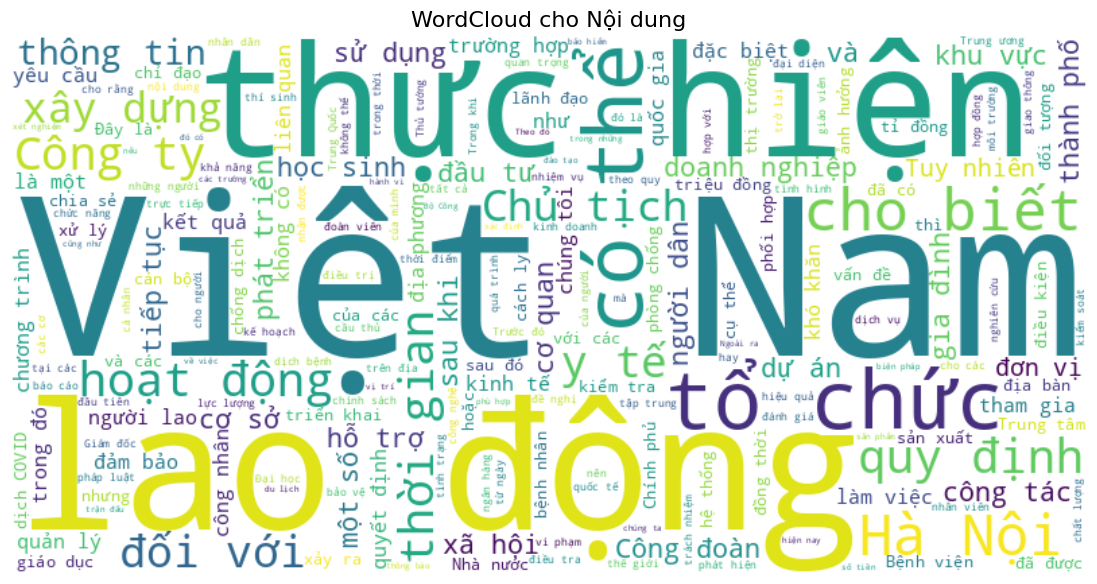

In [20]:
sample_size = min(10000, len(df))  # Chỉ lấy tối đa 10000 dòng
df_sample = df.sample(n=sample_size, random_state=42)

text_titles = " ".join(df_sample["Title"].dropna().astype(str).tolist())
text_contents = " ".join(df_sample["Contents"].dropna().astype(str).tolist())

plt.figure(figsize=(14,7))
wc_title = WordCloud(width=800, height=400, background_color="white").generate(text_titles)
plt.imshow(wc_title, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud cho Tiêu đề", fontsize=16)
plt.show()

plt.figure(figsize=(14,7))
wc_content = WordCloud(width=800, height=400, background_color="white").generate(text_contents)
plt.imshow(wc_content, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud cho Nội dung", fontsize=16)
plt.show()






>* Có nhiều từ vô nghĩa (stop word)
>* Không phân biệt từ đơn và cụm từ
>* Không có phân tích từ ghép → Mất đi ngữ cảnh




## Process Data

### 1. Loại bỏ HTML, ký tự lạ và chuẩn hoá/hiệu chỉnh chính tả

In [21]:
def clean_html(text):
  if pd.isna(text): return ''

  text = BeautifulSoup(text, 'html.parser').get_text(separator=' ')
  text = re.sub(r'https?://\S+', ' ', text)
  text = re.sub(r'\s+', ' ', text).strip() # bỏ white_space
  return text


def normalize_unicode(text):
    return unicodedata.normalize('NFC', text)


VIETNAMESE_ABBR = {
    r'\bTp[\. ]? ?HCM\b': 'TP.HCM',
    r'\bTP[\. ]? ?HCM\b': 'TP.HCM',
    r'\bHà ?nội\b': 'Hà Nội',
    r'\bViệt ?nam\b': 'Việt Nam',
    r'\bVN\b': 'Việt Nam',
    r'\bvnđ\b': 'đồng',
    r'\bTp[\.]?\b': 'TP.',
}
def normalize_common_phrases(text):
    for pattern, repl in VIETNAMESE_ABBR.items():
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)
    return text

def normalize_special_tokens(text):
    text = re.sub(r'@\w+', '<USER>', text)
    text = re.sub(r'#\w+', '<HASHTAG>', text)
    text = re.sub(r'https?://\S+', '<URL>', text)
    return text

def normalize_vietnamese_text(text):
    text = clean_html(text)
    text = normalize_unicode(text)
    text = normalize_common_phrases(text)
    text = normalize_special_tokens(text)
    return text.strip()

for col in ["Title", "Summary", "Contents"]:
    df[col] = df[col].astype(str).apply(normalize_vietnamese_text)



In [22]:
words = list(itertools.chain.from_iterable(df["Contents"].str.split()))
Counter(words).most_common(20)

[('và', 1937323),
 ('của', 1621404),
 ('có', 1527640),
 ('các', 1525585),
 ('cho', 1129769),
 ('là', 1120038),
 ('được', 1059125),
 ('với', 1053100),
 ('trong', 1048511),
 ('đã', 1005732),
 ('người', 822414),
 ('không', 815524),
 ('công', 805589),
 ('để', 707172),
 ('một', 648956),
 ('tại', 630265),
 ('-', 622892),
 ('đến', 613464),
 ('động', 601304),
 ('về', 596967)]

In [23]:
print(df[['Contents']].describe())

       Contents
count    313320
unique   284609
top         nan
freq       5557


### 2. Loại bỏ duplicates

In [24]:
print("Trước khi loại duplicate:", len(df))

# Loại bỏ các dòng trùng hoàn toàn (tất cả cột giống nhau)
df = df.drop_duplicates(keep='first')
df = df.drop_duplicates(subset=['Contents'], keep='first')
df = df.reset_index(drop=True)

print("Sau khi loại duplicate hoàn toàn, Contents:", len(df))

Trước khi loại duplicate: 313320
Sau khi loại duplicate hoàn toàn, Contents: 284609


In [25]:
# Xóa
before = len(df)
df = df[df['Title'] != df['Summary']].reset_index(drop=True)
print(f"Đã xóa {before - len(df):,} → Còn {len(df):,} dòng")

Đã xóa 5 → Còn 284,604 dòng


In [26]:
# Kiểm tra
same = (df['Title'] == df['Summary']).sum()
print(f"Title = Summary: {same:,} dòng ({same/len(df)*100:.1f}%)")
if same > 0:
    print(df[df['Title'] == df['Summary']][['Title', 'Summary']].head(3))

Title = Summary: 0 dòng (0.0%)


### 3. Xóa dòng contents hoặc summary bị null

In [27]:
print(len(df))

df = df.dropna(subset=['Contents'])
df = df[df['Contents'].str.strip() != '']

len(df)

284604


284604

In [28]:
print(len(df))

df = df.dropna(subset=['Summary'])
df = df[df['Summary'].str.strip() != '']

len(df)

284604


284604

In [29]:
# Kiểm tra lại cột null
print(df.isna().sum())

URL             0
Title           0
Summary         0
Contents        0
Date            0
Author(s)     635
Category        0
Tags            0
word_count      0
dtype: int64


### 4. Xóa dòng có Contents, Title, Summary quá ngưỡng

In [30]:
# Đếm số khoảng trắng
word_counts = df['Contents'].fillna('').str.count(' ')

# Lọc: >= 50 từ VÀ <= 1200 từ
df = df[(word_counts >= 49) & (word_counts <= 1199)].reset_index(drop=True)

print(f"Sau khi lọc: {len(df):,} dòng")
print(f"Đã xóa các bài < 50 từ và > 1200 từ")

Sau khi lọc: 276,178 dòng
Đã xóa các bài < 50 từ và > 1200 từ


In [31]:
# Đếm số khoảng trắng
word_counts = df['Title'].fillna('').str.count(' ')

# Lọc: >= 3 từ VÀ <= 25 từ
df = df[(word_counts >= 2) & (word_counts <= 24)].reset_index(drop=True)

print(f"Sau khi lọc: {len(df):,} dòng")
print(f"Đã xóa các bài < 3 từ và > 25 từ")

Sau khi lọc: 275,856 dòng
Đã xóa các bài < 3 từ và > 25 từ


In [32]:
# Đếm số khoảng trắng
word_counts = df['Summary'].fillna('').str.count(' ')

# Lọc: >= 10 và <=150
df = df[(word_counts >= 9) & (word_counts <= 149)].reset_index(drop=True)

print(f"Sau khi lọc: {len(df):,} dòng")
print(f"Đã xóa các bài Summary < 10 từ và > 150 từ")

Sau khi lọc: 275,650 dòng
Đã xóa các bài Summary < 10 từ và > 150 từ


### 5. Xóa cột không cần thiết

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275650 entries, 0 to 275649
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   URL         275650 non-null  object        
 1   Title       275650 non-null  object        
 2   Summary     275650 non-null  object        
 3   Contents    275650 non-null  object        
 4   Date        275650 non-null  datetime64[ns]
 5   Author(s)   275290 non-null  object        
 6   Category    275650 non-null  object        
 7   Tags        275650 non-null  object        
 8   word_count  275650 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 18.9+ MB


In [34]:
df = df[['Title', 'Summary', 'Contents', 'Category']]

## Data Postprocess

In [35]:
df.sample(n=1)

,Title,Summary,Contents,Category
128898,Lấy ý kiến góp ý vào dự thảo văn kiện trình Đại hội XIII của Đảng,"Ngày 27.10, LĐLĐ Thừa Thiên - Huế tổ chức Hội nghị lấy ý kiến góp ý vào dự thảo văn kiện trình Đại hội đại biểu toàn quốc lần thứ XIII của Đảng.","Tại hội nghị, Phó Chủ tịch LĐLĐ tỉnh Thừa Thiên - Huế Trần Quang Vinh gợi ý, các ý kiến góp ý cần tập trung vào những vấn đề chung trong các văn kiện trình Đại hội XIII của Đảng như chủ đề, phương châm chỉ đạo, mục tiêu, những dấu ấn nổi bật trong thực hiện Nghị quyết Đại hội XII; Nguyên nhân, bài học kinh nghiệm; quan điểm chỉ đạo, định hướng phát triển đất nước giai đoạn 2021 - 2030, tầm nhìn đến năm 2045 xuất phát từ thực tiễn triển khai tại địa phương, cơ quan đơn vị, trong đó có các vấn đề về tổ chức Công đoàn, đời sống người lao động, phát triển kinh tế. Nhiều ý kiến của đại biểu quan tâm đến các vấn đề như: Nâng cao vai trò, vị thế của tổ chức Công đoàn; chăm lo đời sống vật chất và tinh thần của người lao động, gắn với phát triển giai cấp công nhân cả về lượng và lượng; nâng cao bản lĩnh chính trị, trình độ học vấn, chuyên môn, kỹ năng nghề nghiệp, tác phong công nghiệp, kỷ luật lao động thích ứng với cuộc Cách mạng công nghiệp lần thứ tư. Phát biểu kết thúc hội nghị, Phó Chủ tịch LĐLĐ tỉnh Trần Quang Vinh ghi nhận các ý kiến tâm huyết của đại biểu. LĐLĐ tỉnh sẽ tổng hợp đúng, đủ các ý kiến của đại biểu gửi lên cấp trên.",Công đoàn


In [36]:
# Số lượng bài ngoài ngưỡng
df['word_count'] = df['Contents'].fillna('').str.count(' ') + 1

under_50 = (df['word_count'] < 50).sum()
over_1200 = (df['word_count'] > 1200).sum()

print(f"< 50 từ: {under_50:,} ({under_50/len(df)*100:.2f}%)")
print(f"> 1200 từ: {over_1200:,} ({over_1200/len(df)*100:.2f}%)")
print(f"Trung bình: {df['word_count'].mean():.1f} từ")

< 50 từ: 0 (0.00%)
> 1200 từ: 0 (0.00%)
Trung bình: 468.3 từ


In [37]:
# Kiểm tra trùng lặp cả row
has_dup = df.duplicated().sum()
print('Sô dòng trùng lặp: ', has_dup)

Sô dòng trùng lặp:  0


In [38]:
print(df.isna().sum())

Title         0
Summary       0
Contents      0
Category      0
word_count    0
dtype: int64


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275650 entries, 0 to 275649
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Title       275650 non-null  object
 1   Summary     275650 non-null  object
 2   Contents    275650 non-null  object
 3   Category    275650 non-null  object
 4   word_count  275650 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 10.5+ MB


In [40]:
# Đếm số dòng Title giống Summary (chính xác 100%)
same_count = (df['Title'] == df['Summary']).sum()

print(f"Số dòng có Title giống Summary: {same_count}")
print(f"Tỷ lệ: {same_count/len(df)*100:.2f}%")

# Xem các dòng giống nhau
if same_count > 0:
    same_rows = df[df['Title'] == df['Summary']]
    print(f"\nVí dụ {min(3, len(same_rows))} dòng giống nhau:")
    for idx, row in same_rows.head(3).iterrows():
        print(f"\n  Index {idx}:")
        print(f"  Title: {row['Title']}")
        print(f"  Summary: {row['Summary']}")

Số dòng có Title giống Summary: 0
Tỷ lệ: 0.00%


In [41]:
# Số lượng bài ngoài ngưỡng
df['word_count'] = df['Summary'].fillna('').str.count(' ') + 1

# Thống kê
under_10 = df[df['word_count'] < 10]
print(f"Số dòng có Summary < 10 từ: {len(under_10):,}")
print(f"Tỷ lệ: {len(under_10)/len(df)*100:.2f}%")

over_150 = df[df['word_count'] > 150]
print(f"Số dòng có Summary > 150 từ: {len(over_150):,}")
print(f"Tỷ lệ: {len(over_150)/len(df)*100:.2f}%")


Số dòng có Summary < 10 từ: 0
Tỷ lệ: 0.00%
Số dòng có Summary > 150 từ: 0
Tỷ lệ: 0.00%


In [42]:
# Số lượng bài ngoài ngưỡng
df['word_count'] = df['Title'].fillna('').str.count(' ') + 1

# Thống kê
under_3 = df[df['word_count'] < 3]
over_25 = df[df['word_count'] > 25]

print(f"Số dòng có Title > 25 từ: {len(over_25):,}")
print(f"Tỷ lệ: {len(over_25)/len(df)*100:.2f}%")

print(f"Số dòng có Title < 3 từ: {len(under_3):,}")
print(f"Tỷ lệ: {len(under_3)/len(df)*100:.2f}%")


Số dòng có Title > 25 từ: 0
Tỷ lệ: 0.00%
Số dòng có Title < 3 từ: 0
Tỷ lệ: 0.00%


In [43]:
# Số lượng bài ngoài ngưỡng
df['word_count'] = df['Contents'].fillna('').str.count(' ') + 1

# Thống kê
under_50 = df[df['word_count'] < 50]
over_1200 = df[df['word_count'] > 1200]

print(f"Số dòng có Contents > 1200 từ: {len(over_1200):,}")
print(f"Tỷ lệ: {len(over_1200)/len(df)*100:.2f}%")

print(f"Số dòng có Contents < 50 từ: {len(under_50):,}")
print(f"Tỷ lệ: {len(under_50)/len(df)*100:.2f}%")


Số dòng có Contents > 1200 từ: 0
Tỷ lệ: 0.00%
Số dòng có Contents < 50 từ: 0
Tỷ lệ: 0.00%


In [44]:
# Khởi tạo tokenizer
encoding = tiktoken.get_encoding("cl100k_base")

def count_tokens_batch(texts):
    """Đếm tokens cho nhiều văn bản"""
    tokens_list = []
    for text in tqdm(texts, desc="Counting tokens"):
        if pd.isna(text) or text == '':
            tokens_list.append(0)
        else:
            tokens_list.append(len(encoding.encode(str(text))))
    return np.array(tokens_list)

# Đếm tokens
print("Đang đếm tokens cho Title...")
title_tokens = count_tokens_batch(df['Title'].values)

print("Đang đếm tokens cho Contents...")
contents_tokens = count_tokens_batch(df['Contents'].values)

# Lưu vào DataFrame
df['title_tokens'] = title_tokens
df['contents_tokens'] = contents_tokens
df['total_tokens'] = title_tokens + contents_tokens

# Thống kê
print("\n" + "=" * 60)
print("📊 KẾT QUẢ:")
print("=" * 60)
print(f"Tổng tokens toàn dataset: {df['total_tokens'].sum():,}")
print(f"Trung bình tokens/bài: {df['total_tokens'].mean():.1f}")

Đang đếm tokens cho Title...


Counting tokens: 100%|██████████| 275650/275650 [00:06<00:00, 43756.82it/s]


Đang đếm tokens cho Contents...


Counting tokens: 100%|██████████| 275650/275650 [02:34<00:00, 1789.93it/s]


📊 KẾT QUẢ:
Tổng tokens toàn dataset: 298,402,804
Trung bình tokens/bài: 1082.5


In [45]:
category_counts = df['Category'].value_counts()
print(category_counts)


Category
Xã hội                        53264
Thể thao                      30219
Pháp luật                     27844
Thế giới                      27741
Kinh doanh                    26042
Công đoàn                     22233
Văn hóa - Giải trí            18092
Thời sự                       14590
Giáo dục                      11271
Sức khỏe                      10857
Bạn đọc                        7961
Media                          7194
Bất động sản                   5634
Gia đình - Hôn nhân            4207
Xe +                           3671
Tấm Lòng Vàng                  1832
Công nghệ                      1323
Lưu trữ                         401
Diễn đàn                        277
Tin tức việc làm                269
Tin hoạt động                   220
Lao Động & Đời sống             163
Lao Động cuối tuần              156
Sự kiện Bình luận                57
Tin địa phương                   32
Quỹ TLV                          27
Tin bài xem thêm                 13
Thông tin doanh ngh

In [46]:
MIN_SAMPLES = 100

category_counts = df['Category'].value_counts()
rare_categories = category_counts[category_counts < MIN_SAMPLES].index

df['Category'] = df['Category'].replace(rare_categories, 'Other')


In [47]:
category_counts = df['Category'].value_counts()
print(category_counts)


Category
Xã hội                 53264
Thể thao               30219
Pháp luật              27844
Thế giới               27741
Kinh doanh             26042
Công đoàn              22233
Văn hóa - Giải trí     18092
Thời sự                14590
Giáo dục               11271
Sức khỏe               10857
Bạn đọc                 7961
Media                   7194
Bất động sản            5634
Gia đình - Hôn nhân     4207
Xe +                    3671
Tấm Lòng Vàng           1832
Công nghệ               1323
Lưu trữ                  401
Diễn đàn                 277
Tin tức việc làm         269
Tin hoạt động            220
Other                    189
Lao Động & Đời sống      163
Lao Động cuối tuần       156
Name: count, dtype: int64


## Data split

In [48]:
df = df[['Title', 'Summary', 'Contents', 'Category']].dropna().reset_index(drop=True)

train_val_df, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df['Category']
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=1/9,
    random_state=42,
    stratify=train_val_df['Category']
)

In [49]:
def check_distribution(df, name):
    print(f"\n{name}")
    print(df['Category'].value_counts())

check_distribution(train_df, "TRAIN")
check_distribution(val_df, "VAL")
check_distribution(test_df, "TEST")



TRAIN
Category
Xã hội                 42611
Thể thao               24175
Pháp luật              22275
Thế giới               22193
Kinh doanh             20834
Công đoàn              17787
Văn hóa - Giải trí     14474
Thời sự                11672
Giáo dục                9017
Sức khỏe                8685
Bạn đọc                 6369
Media                   5755
Bất động sản            4507
Gia đình - Hôn nhân     3365
Xe +                    2937
Tấm Lòng Vàng           1466
Công nghệ               1059
Lưu trữ                  321
Diễn đàn                 221
Tin tức việc làm         215
Tin hoạt động            176
Other                    151
Lao Động & Đời sống      131
Lao Động cuối tuần       124
Name: count, dtype: int64

VAL
Category
Xã hội                 5326
Thể thao               3022
Pháp luật              2784
Thế giới               2774
Kinh doanh             2604
Công đoàn              2223
Văn hóa - Giải trí     1809
Thời sự                1459
Giáo dục               1

In [50]:
os.makedirs("/kaggle/working/data", exist_ok=True)  # Kaggle
# hoặc nếu bạn đang chạy trên Colab:
# os.makedirs("/content/data", exist_ok=True)

# Kaggle
train_df.to_csv("/kaggle/working/data/dataset_train.csv", index=False)
val_df.to_csv("/kaggle/working/data/dataset_val.csv", index=False)
test_df.to_csv("/kaggle/working/data/dataset_test.csv", index=False)

# Colab
# train_df.to_csv("/content/data/dataset_train.csv", index=False)
# val_df.to_csv("/content/data/dataset_val.csv", index=False)
# test_df.to_csv("/content/data/dataset_test.csv", index=False)


print("Đã lưu thành công 3 file:")

Đã lưu thành công 3 file:
